In [10]:
from pathlib import Path
from collections import defaultdict, deque
import duckdb
from IPython.display import display, HTML

ROOT = Path().resolve().parent
db   = duckdb.connect(str(ROOT / 'data' / 'mathlib.db'), read_only=True)

COMMIT = '29dcec074de168ac2bf835a77ef68bbe069194c5'

print('Loading dependency edges …', end=' ', flush=True)
_adj: dict[str, list[str]] = defaultdict(list)
for src, dst in db.execute('SELECT src, dst FROM dependencies').fetchall():
    _adj[src].append(dst)
print(f'{sum(len(v) for v in _adj.values()):,} edges loaded.')

Loading dependency edges … 387,509 edges loaded.


387,509 edges loaded.


In [11]:
# ── Graph analysis helpers ─────────────────────────────────────────────────

def _bfs(start: str) -> dict[str, int]:
    """BFS from start following dependency edges. Returns {node: min_distance}."""
    dist = {start: 0}
    q = deque([start])
    while q:
        node = q.popleft()
        for nb in _adj.get(node, []):
            if nb not in dist:
                dist[nb] = dist[node] + 1
                q.append(nb)
    return dist


def _longest_path(nodes: set[str], start: str) -> tuple[int, list[str]]:
    """
    Longest path from *start* in the induced subgraph via topological DP.
    Returns (length, path_as_list_of_node_names).
    """
    in_deg = {n: 0 for n in nodes}
    for n in nodes:
        for nb in _adj.get(n, []):
            if nb in nodes:
                in_deg[nb] += 1

    dp   = {n: -1   for n in nodes}
    prev = {n: None for n in nodes}
    dp[start] = 0

    queue = deque(n for n in nodes if in_deg[n] == 0)
    while queue:
        node = queue.popleft()
        for nb in _adj.get(node, []):
            if nb not in nodes:
                continue
            if dp[node] >= 0 and dp[node] + 1 > dp[nb]:
                dp[nb]   = dp[node] + 1
                prev[nb] = node
            in_deg[nb] -= 1
            if in_deg[nb] == 0:
                queue.append(nb)

    end = max((n for n in nodes if dp[n] >= 0), key=lambda n: dp[n], default=start)
    path, cur = [], end
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return dp[end], path


print('Analysis helpers ready.')

Analysis helpers ready.


In [12]:
# ── HTML rendering ─────────────────────────────────────────────────────────

_CSS = '''
<style>
.dt-box      { font-family: monospace; margin: 10px 0; }
.dt-header   { margin-bottom: 8px; }
.dt-name     { font-size: 1.15em; font-weight: bold; color: #0366d6; }
.dt-meta     { color: #888; font-size: 0.82em; margin-left: 8px; }
.dt-badge    { font-size: 0.75em; background: #24292e; color: #fff;
               padding: 2px 8px; border-radius: 3px;
               text-decoration: none; margin-left: 10px; }
.dt-stats    { display: flex; gap: 24px; margin: 10px 0;
               padding: 8px 12px; background: #f6f8fa;
               border-radius: 4px; font-size: 0.88em; }
.dt-stat     { text-align: center; }
.dt-stat-n   { font-size: 1.4em; font-weight: bold; color: #0366d6; }
.dt-stat-l   { color: #555; font-size: 0.8em; }
.dt-section  { font-weight: bold; color: #444; margin: 12px 0 4px 0;
               border-bottom: 1px solid #eee; padding-bottom: 3px; }
.dt-bar-row  { display: flex; align-items: center; margin: 2px 0;
               font-size: 0.82em; }
.dt-bar-lbl  { width: 60px; color: #666; text-align: right;
               padding-right: 8px; flex-shrink: 0; }
.dt-bar-fill { background: #4477aa; height: 14px; border-radius: 2px;
               min-width: 2px; }
.dt-bar-n    { margin-left: 6px; color: #555; }
.dt-chain    { background: #f6f8fa; border-radius: 4px;
               padding: 10px 14px; margin: 4px 0; }
.dt-chain-step { display: flex; align-items: baseline; margin: 3px 0;
                 font-size: 0.84em; }
.dt-chain-arrow { color: #aaa; margin-right: 4px; flex-shrink: 0; }
.dt-chain-name  { color: #0366d6; }
.dt-chain-kind  { color: #aaa; font-size: 0.8em; margin-left: 5px; }
.dt-direct   { display: flex; flex-wrap: wrap; gap: 6px; margin: 6px 0; }
.dt-dep-chip { background: #e8f0fe; color: #1a73e8;
               padding: 2px 8px; border-radius: 12px;
               font-size: 0.78em; white-space: nowrap; }
.dt-dep-chip.term { background: #fce8e6; color: #c5221f; }
</style>
'''
_CSS_EMITTED = False


def _kind_row(name: str) -> tuple[str, str, str]:
    r = db.execute(
        'SELECT kind, module, file_path, start_line '
        'FROM declarations d LEFT JOIN lean_source ls ON ls.name = d.name '
        'WHERE d.name = ?', [name]
    ).fetchone()
    if r:
        return r[0] or '', r[1] or '', r[2], r[3]
    return '', '', None, None


def show_dep_tree(name: str, max_bar_width: int = 50) -> None:
    """
    Display the transitive dependency tree statistics for a Lean declaration.

    Shows:
      - Summary stats (total reachable deps, BFS depth, longest chain)
      - Histogram of nodes at each BFS level
      - The longest dependency chain, step by step
      - Direct (level-1) dependencies as chips

    Parameters
    ----------
    name          : full Lean declaration name, e.g. 'Finset.prod_range_succ'
    max_bar_width : pixel width of the widest histogram bar
    """
    global _CSS_EMITTED
    if not _CSS_EMITTED:
        display(HTML(_CSS))
        _CSS_EMITTED = True

    # ── Validate ──────────────────────────────────────────────────────────
    exists = db.execute(
        'SELECT name FROM declarations WHERE name = ?', [name]
    ).fetchone()
    if not exists:
        candidates = db.execute(
            'SELECT name FROM declarations WHERE name LIKE ? LIMIT 10',
            [f'%{name}%']
        ).fetchall()
        html = (f'<div style="color:#c00;font-family:monospace">'
                f'Not found: <b>{name}</b></div>')
        if candidates:
            html += ('<div style="font-family:monospace;margin-top:6px">'
                     'Did you mean:<ul>'
                     + ''.join(f'<li>{r[0]}</li>' for r in candidates)
                     + '</ul></div>')
        display(HTML(html))
        return

    kind, module, file_path, start_line = _kind_row(name)

    gh_url = (
        f'https://github.com/leanprover-community/mathlib4/blob/{COMMIT}'
        f'/{file_path}#L{start_line}'
        if file_path and start_line else None
    )
    badge = (
        f'<a class="dt-badge" href="{gh_url}" target="_blank">View on GitHub ↗</a>'
        if gh_url else ''
    )

    # ── BFS ───────────────────────────────────────────────────────────────
    dist          = _bfs(name)
    all_nodes     = set(dist)
    total_deps    = len(all_nodes) - 1

    if total_deps == 0:
        display(HTML(
            f'<div class="dt-box">'
            f'<div class="dt-header">'
            f'  <span class="dt-name">{name}</span>'
            f'  <span class="dt-meta">{kind} — {module}</span>'
            f'  {badge}'
            f'</div>'
            f'<div style="color:#888;font-style:italic;font-family:monospace;">'
            f'No tracked dependencies — proved by automation (omega / simp / decide)'
            f' or is a primitive axiom.</div>'
            f'</div>'
        ))
        return

    max_bfs = max(dist.values())

    level_count: dict[int, int] = defaultdict(int)
    for d in dist.values():
        level_count[d] += 1

    # ── Longest path ──────────────────────────────────────────────────────
    longest_len, longest_path = _longest_path(all_nodes, name)

    # ── Direct deps (level 1) ─────────────────────────────────────────────
    direct = [n for n, d in dist.items() if d == 1]

    # ── Build HTML ────────────────────────────────────────────────────────
    parts = [f'<div class="dt-box">']

    # Header
    parts.append(
        f'<div class="dt-header">'
        f'  <span class="dt-name">{name}</span>'
        f'  <span class="dt-meta">{kind} — {module}</span>'
        f'  {badge}'
        f'</div>'
    )

    # Stat tiles
    parts.append(
        f'<div class="dt-stats">'
        f'  <div class="dt-stat"><div class="dt-stat-n">{total_deps:,}</div>'
        f'  <div class="dt-stat-l">transitive deps</div></div>'
        f'  <div class="dt-stat"><div class="dt-stat-n">{max_bfs}</div>'
        f'  <div class="dt-stat-l">max BFS depth</div></div>'
        f'  <div class="dt-stat"><div class="dt-stat-n">{longest_len}</div>'
        f'  <div class="dt-stat-l">longest chain</div></div>'
        f'  <div class="dt-stat"><div class="dt-stat-n">{len(direct)}</div>'
        f'  <div class="dt-stat-l">direct deps</div></div>'
        f'</div>'
    )

    # Histogram
    parts.append('<div class="dt-section">Deps by BFS level</div>')
    max_count = max(level_count.get(l, 0) for l in range(1, max_bfs + 1))
    for level in range(1, max_bfs + 1):
        n   = level_count.get(level, 0)
        pct = n / max_count if max_count > 0 else 0
        bar_w = max(2, int(pct * max_bar_width * 8))  # px
        parts.append(
            f'<div class="dt-bar-row">'
            f'  <div class="dt-bar-lbl">level {level}</div>'
            f'  <div class="dt-bar-fill" style="width:{bar_w}px"></div>'
            f'  <div class="dt-bar-n">{n:,}</div>'
            f'</div>'
        )

    # Longest chain
    parts.append(f'<div class="dt-section">Longest dependency chain &nbsp;'
                 f'<span style="font-weight:normal;color:#888">({longest_len + 1} steps)</span></div>')
    parts.append('<div class="dt-chain">')
    for i, node in enumerate(longest_path):
        k, *_ = _kind_row(node)
        indent = '&nbsp;' * (i * 4)
        arrow  = '→ ' if i > 0 else ''
        short  = node if len(node) <= 65 else node[:62] + '…'
        parts.append(
            f'<div class="dt-chain-step">'
            f'  {indent}'
            f'  <span class="dt-chain-arrow">{arrow}</span>'
            f'  <span class="dt-chain-name">{short}</span>'
            f'  <span class="dt-chain-kind">[{k}]</span>'
            f'</div>'
        )
    parts.append('</div>')

    # Direct deps chips
    parts.append('<div class="dt-section">Direct dependencies</div>')
    parts.append('<div class="dt-direct">')
    for dep in sorted(direct):
        k, *_ = _kind_row(dep)
        cls = 'dt-dep-chip term' if k not in ('theorem', 'lemma', '') else 'dt-dep-chip'
        parts.append(f'<span class="{cls}">{dep}</span>')
    parts.append('</div>')

    parts.append('</div>')
    display(HTML('\n'.join(parts)))


print('show_dep_tree() ready.')

show_dep_tree() ready.


## Dependency Tree Explorer

Set `THEOREM` below to any Lean declaration name and re-run the cell.  
If the name isn't found, the nearest matches are suggested.

**What the output shows:**
- **Transitive deps** — total number of declarations reachable by following dependencies recursively  
- **Max BFS depth** — the shortest path distance to the furthest dependency  
- **Longest chain** — the longest sequence T → A → B → C → … in the DAG  
- **Histogram** — how many nodes sit at each hop-distance from the theorem  
- **Direct dependencies** — the immediate level-1 predecessors (blue = theorem/lemma, red = def/instance)

In [13]:
THEOREM = 'Nat.add_comm'

show_dep_tree(THEOREM)

## Find theorems by keyword

Use `find_theorems(keyword)` to search declaration names and docstrings, then paste a result into `THEOREM` above.

In [14]:
def find_theorems(keyword: str, limit: int = 20) -> None:
    """
    Search for declarations whose name or docstring contains *keyword*.
    Results are sorted: docstring matches first, then name-only matches.
    """
    rows = db.execute("""
        SELECT d.name, d.kind, d.module,
               CASE WHEN lower(ds.docstring) LIKE lower(?) THEN 1 ELSE 0 END AS doc_match,
               ds.docstring
        FROM declarations d
        LEFT JOIN docstrings ds ON d.name = ds.name
        WHERE lower(d.name) LIKE lower(?)
           OR lower(ds.docstring) LIKE lower(?)
        ORDER BY doc_match DESC, d.module, d.name
        LIMIT ?
    """, [f'%{keyword}%', f'%{keyword}%', f'%{keyword}%', limit]).fetchall()

    if not rows:
        display(HTML(f'<div style="color:#c00">No results for <b>{keyword}</b></div>'))
        return

    import re
    parts = [f'<div style="font-family:monospace"><b>{len(rows)} results for "{keyword}"</b></div><hr style="border:none;border-top:1px solid #eee">']
    for name, kind, module, doc_match, doc in rows:
        doc_snip = ''
        if doc:
            # Show a short snippet around the keyword
            idx = doc.lower().find(keyword.lower())
            if idx >= 0:
                lo, hi = max(0, idx - 60), min(len(doc), idx + 100)
                snip = ('…' if lo > 0 else '') + doc[lo:hi] + ('…' if hi < len(doc) else '')
                snip = re.sub(f'(?i)({re.escape(keyword)})', r'<mark>\1</mark>', snip)
                doc_snip = (f'<div style="color:#555;font-size:0.8em;margin:2px 0 0 12px;'
                            f'font-family:sans-serif">📄 {snip}</div>')
        parts.append(
            f'<div style="margin:4px 0">'
            f'<span style="color:#0366d6;font-weight:bold">{name}</span>'
            f'<span style="color:#888;font-size:0.8em;margin-left:8px">{kind} — {module}</span>'
            f'{doc_snip}'
            f'</div>'
        )
    parts.append('<hr style="border:none;border-top:1px solid #eee">')
    display(HTML('\n'.join(parts)))


# ── Example: find theorems related to Fermat's little theorem ─────────────
find_theorems('Fermat')

In [15]:
# ── Show several examples at once ─────────────────────────────────────────
for name in [
    'Nat.factors_lemma',
    'Finset.prod_range_succ',
    'PadicInt.norm_int_lt_one_iff_dvd',
    'Fermat42.not_minimal',
]:
    show_dep_tree(name)
    print()

## Primitive Concepts

**Primitives** are declarations with no outgoing dependency edges — i.e., the leaves of the DAG.
They fall into two categories:

- **True axioms** (`kind = axiom`) — foundational by design
- **Automation leaves** — theorems proved by `omega` / `simp` / `decide` / `ring` with no recorded premises; they appear as leaves because the tactic tracer recorded no explicit dependencies

The most *interesting* primitives are those with high **in-degree**: cited many times by the rest of Mathlib despite having nothing beneath them in our graph.

Adjust `MIN_IN_DEGREE`, `KIND_FILTER`, and `MODULE_FILTER` then re-run.

In [16]:
MIN_IN_DEGREE = 10     # only show primitives cited at least this many times
TOP_N         = 80    # max rows to display
KIND_FILTER   = None  # e.g. 'theorem' | 'def' | 'axiom' | None for all kinds
MODULE_FILTER = None  # e.g. 'Mathlib.Data%' | None for all modules

# ── Query ─────────────────────────────────────────────────────────────────
where_extra = ''
params = []
if KIND_FILTER:
    where_extra += " AND d.kind = ?"
    params.append(KIND_FILTER)
if MODULE_FILTER:
    where_extra += " AND d.module LIKE ?"
    params.append(MODULE_FILTER)

prim_rows = db.execute(f"""
    WITH has_out AS (SELECT DISTINCT src FROM dependencies),
         in_counts AS (SELECT dst, COUNT(*) AS cnt FROM dependencies GROUP BY dst)
    SELECT d.name, d.kind, d.module, COALESCE(ic.cnt, 0) AS in_degree
    FROM declarations d
    LEFT JOIN has_out ho ON ho.src = d.name
    LEFT JOIN in_counts ic ON ic.dst = d.name
    WHERE ho.src IS NULL
      AND COALESCE(ic.cnt, 0) >= ?
      {where_extra}
    ORDER BY in_degree DESC
    LIMIT ?
""", [MIN_IN_DEGREE] + params + [TOP_N]).fetchall()

# Summary counts (no extra filters, for context)
total_prim, total_decls = db.execute("""
    WITH has_out AS (SELECT DISTINCT src FROM dependencies)
    SELECT
        (SELECT COUNT(*) FROM declarations d LEFT JOIN has_out ho ON ho.src=d.name WHERE ho.src IS NULL),
        (SELECT COUNT(*) FROM declarations)
""").fetchone()

kind_summary = db.execute("""
    WITH has_out AS (SELECT DISTINCT src FROM dependencies),
         in_counts AS (SELECT dst, COUNT(*) AS cnt FROM dependencies GROUP BY dst)
    SELECT d.kind,
           COUNT(*)                                          AS n_total,
           SUM(CASE WHEN COALESCE(ic.cnt,0) > 0 THEN 1 ELSE 0 END) AS n_cited
    FROM declarations d
    LEFT JOIN has_out ho ON ho.src = d.name
    LEFT JOIN in_counts ic ON ic.dst = d.name
    WHERE ho.src IS NULL
    GROUP BY d.kind
    ORDER BY n_total DESC
""").fetchall()

# ── Render ────────────────────────────────────────────────────────────────
kind_colors = {
    'axiom':    ('#7b2d00', '#ffe0d0'),
    'theorem':  ('#1a56db', '#e8f0fe'),
    'lemma':    ('#1a56db', '#e8f0fe'),
    'def':      ('#0d6832', '#e6f4ea'),
    'instance': ('#5b21b6', '#f3e8ff'),
    'unknown':  ('#555',    '#f0f0f0'),
}

def kind_chip(k):
    fg, bg = kind_colors.get(k, ('#555', '#f0f0f0'))
    return (f'<span style="background:{bg};color:{fg};padding:1px 6px;'
            f'border-radius:10px;font-size:0.78em">{k}</span>')

# Summary bar
summary_html = ''.join(
    f'<span style="margin-right:16px;font-size:0.85em">'
    f'{kind_chip(k)}'
    f' <b>{n:,}</b> total &nbsp; {nc:,} cited'
    f'</span>'
    for k, n, nc in kind_summary
)

# Table rows
row_html = ''
for name, kind, module, in_deg in prim_rows:
    short_mod = module or ''
    name_disp = name if len(name) <= 55 else name[:52] + '…'
    row_html += (
        f'<tr>'
        f'<td style="padding:3px 8px;color:#0366d6;font-weight:bold">{name_disp}</td>'
        f'<td style="padding:3px 8px">{kind_chip(kind)}</td>'
        f'<td style="padding:3px 8px;color:#555;font-size:0.8em">{short_mod}</td>'
        f'<td style="padding:3px 8px;text-align:right;font-weight:bold;color:#333">'
        f'{in_deg:,}</td>'
        f'</tr>'
    )

html = f'''
<div style="font-family:monospace">
  <div style="font-size:1.1em;font-weight:bold;margin-bottom:6px">
    Primitive Concepts
    <span style="font-weight:normal;color:#888;font-size:0.8em">
      — {total_prim:,} of {total_decls:,} declarations have no tracked dependencies
    </span>
  </div>
  <div style="margin-bottom:10px;padding:8px;background:#f6f8fa;border-radius:4px">
    {summary_html}
  </div>
  <div style="color:#555;font-size:0.82em;margin-bottom:6px">
    Showing top {len(prim_rows)} with in-degree ≥ {MIN_IN_DEGREE}
    {("  ·  kind = " + KIND_FILTER) if KIND_FILTER else ""}
    {("  ·  module LIKE " + MODULE_FILTER) if MODULE_FILTER else ""}
  </div>
  <table style="border-collapse:collapse;width:100%;font-size:0.84em">
    <thead>
      <tr style="border-bottom:2px solid #ddd;background:#f6f8fa">
        <th style="padding:4px 8px;text-align:left">Name</th>
        <th style="padding:4px 8px;text-align:left">Kind</th>
        <th style="padding:4px 8px;text-align:left">Module</th>
        <th style="padding:4px 8px;text-align:right">In-degree</th>
      </tr>
    </thead>
    <tbody>
      {row_html}
    </tbody>
  </table>
</div>
'''
display(HTML(html))

Name,Kind,Module,In-degree
Eq.symm,theorem,Init.Prelude,"1,730"
Iff.rfl,theorem,Init.Core,"1,413"
Function.Injective,theorem,Init.Data.Function,"1,268"
Set.range,def,Mathlib.Data.Set.Operations,"1,055"
add_comm,unknown,Mathlib.Algebra.Group.Defs,950
Fintype.card,def,Mathlib.Data.Fintype.Card,810
Or.inl,theorem,Init.Prelude,802
Function.comp_apply,theorem,Init.Core,801
Or.inr,theorem,Init.Prelude,760
eq_comm,theorem,Init.Core,701


## Connectedness Outliers

Declarations that sit at extremes of the dependency graph:

| Metric | What it measures |
|---|---|
| **In-degree** | How many declarations cite this one (a proxy for "importance") |
| **Out-degree** | How many dependencies this declaration has (a proxy for "complexity") |
| **Hub score** | In-degree × out-degree — nodes that are both widely cited *and* complex |
| **Module coupling** | Which modules have the densest cross-module dependency traffic |

Change `TOP_N` or uncomment `MODULE_FILTER` to focus on a subarea.

In [17]:
TOP_N         = 25    # rows per section
MODULE_FILTER = None  # e.g. 'Mathlib.Analysis%' to restrict all sections, or None for all

# ── Build degree dicts from the in-memory adjacency list ──────────────────
from collections import defaultdict as _dd

_in_deg: dict[str, int] = _dd(int)
for _src, _nbs in _adj.items():
    for _dst in _nbs:
        _in_deg[_dst] += 1
_out_deg: dict[str, int] = {n: len(nbs) for n, nbs in _adj.items()}

# ── Helpers ───────────────────────────────────────────────────────────────
_mod_cache: dict[str, tuple[str,str]] = {}
def _meta(name: str) -> tuple[str, str]:
    """Return (kind, module) for a declaration, cached."""
    if name not in _mod_cache:
        r = db.execute(
            'SELECT kind, module FROM declarations WHERE name = ?', [name]
        ).fetchone()
        _mod_cache[name] = (r[0] or '', r[1] or '') if r else ('', '')
    return _mod_cache[name]

def _table(title: str, rows: list[tuple], col_headers: list[str], col_fmts: list) -> str:
    """Render a simple HTML table."""
    head = ''.join(
        f'<th style="padding:4px 10px;text-align:{"right" if i>0 else "left"}">{h}</th>'
        for i, h in enumerate(col_headers)
    )
    body = ''
    for row in rows:
        cells = ''
        for i, (val, fmt) in enumerate(zip(row, col_fmts)):
            align = 'right' if i > 0 else 'left'
            cells += f'<td style="padding:3px 10px;text-align:{align}">{fmt(val)}</td>'
        body += f'<tr style="border-top:1px solid #f0f0f0">{cells}</tr>'
    return (
        f'<div style="margin:16px 0">'
        f'<div style="font-weight:bold;font-size:0.95em;color:#333;margin-bottom:4px">{title}</div>'
        f'<table style="border-collapse:collapse;font-family:monospace;font-size:0.83em;width:100%">'
        f'<thead><tr style="background:#f6f8fa;border-bottom:2px solid #ddd">{head}</tr></thead>'
        f'<tbody>{body}</tbody></table></div>'
    )

def _name_cell(name: str) -> str:
    disp = name if len(name) <= 55 else name[:52] + '…'
    return f'<span style="color:#0366d6;font-weight:bold">{disp}</span>'

def _meta_cell(name: str) -> str:
    k, m = _meta(name)
    fg, bg = kind_colors.get(k, ('#555', '#f0f0f0'))
    chip = (f'<span style="background:{bg};color:{fg};padding:1px 5px;'
            f'border-radius:9px;font-size:0.8em">{k}</span>')
    return f'{chip} <span style="color:#888;font-size:0.8em">{m}</span>'

# ── Optionally restrict to a module ───────────────────────────────────────
if MODULE_FILTER:
    _mod_names = frozenset(
        r[0] for r in db.execute(
            'SELECT name FROM declarations WHERE module LIKE ?', [MODULE_FILTER]
        ).fetchall()
    )
    _in_deg_use  = {n: v for n, v in _in_deg.items()  if n in _mod_names}
    _out_deg_use = {n: v for n, v in _out_deg.items() if n in _mod_names}
else:
    _in_deg_use  = _in_deg
    _out_deg_use = _out_deg

# ── Section 1: Top in-degree ──────────────────────────────────────────────
top_in = sorted(_in_deg_use.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

# ── Section 2: Top out-degree ─────────────────────────────────────────────
top_out = sorted(_out_deg_use.items(), key=lambda x: x[1], reverse=True)[:TOP_N]

# ── Section 3: Hub score (in × out) ──────────────────────────────────────
all_names_set = set(_in_deg_use) | set(_out_deg_use)
hub_scores = [
    (n, _in_deg_use.get(n, 0), _out_deg_use.get(n, 0),
     _in_deg_use.get(n, 0) * _out_deg_use.get(n, 0))
    for n in all_names_set
    if _in_deg_use.get(n, 0) > 0 and _out_deg_use.get(n, 0) > 0
]
top_hub = sorted(hub_scores, key=lambda x: x[3], reverse=True)[:TOP_N]

# ── Section 4: Module coupling (cross-module dep traffic) ─────────────────
mod_cross = db.execute(f"""
    SELECT s.module AS src_mod, d.module AS dst_mod, COUNT(*) AS n
    FROM dependencies dep
    JOIN declarations s ON s.name = dep.src
    JOIN declarations d ON d.name = dep.dst
    WHERE s.module <> d.module
      {'AND s.module LIKE ?' if MODULE_FILTER else ''}
      AND s.module IS NOT NULL AND d.module IS NOT NULL
    GROUP BY 1, 2
    ORDER BY n DESC
    LIMIT {TOP_N}
""", ([MODULE_FILTER] if MODULE_FILTER else [])).fetchall()

# ── Render ────────────────────────────────────────────────────────────────
parts = [f'<div style="font-family:monospace">']

if MODULE_FILTER:
    parts.append(f'<div style="color:#888;font-size:0.85em;margin-bottom:8px">'
                 f'Filtered to: <code>{MODULE_FILTER}</code></div>')

parts.append(_table(
    f'Top {TOP_N} by In-degree &nbsp;<span style="font-weight:normal;color:#888;font-size:0.8em">'
    f'(most cited — how many declarations depend on this one)</span>',
    [(n, c, n) for n, c in top_in],
    ['Name', 'In-degree', 'Kind / Module'],
    [_name_cell, lambda v: f'<b>{v:,}</b>', _meta_cell],
))

parts.append(_table(
    f'Top {TOP_N} by Out-degree &nbsp;<span style="font-weight:normal;color:#888;font-size:0.8em">'
    f'(most dependencies — how many this one cites)</span>',
    [(n, c, n) for n, c in top_out],
    ['Name', 'Out-degree', 'Kind / Module'],
    [_name_cell, lambda v: f'<b>{v:,}</b>', _meta_cell],
))

parts.append(_table(
    f'Top {TOP_N} Hub Score &nbsp;<span style="font-weight:normal;color:#888;font-size:0.8em">'
    f'(in-degree × out-degree — important AND complex)</span>',
    [(n, ind, outd, hub, n) for n, ind, outd, hub in top_hub],
    ['Name', 'In', 'Out', 'Hub score', 'Kind / Module'],
    [_name_cell,
     lambda v: str(v),
     lambda v: str(v),
     lambda v: f'<b>{v:,}</b>',
     _meta_cell],
))

# Module coupling table
mc_rows = ''
for src_mod, dst_mod, n in mod_cross:
    sm = src_mod.replace('Mathlib.', '') if src_mod else src_mod
    dm = dst_mod.replace('Mathlib.', '') if dst_mod else dst_mod
    mc_rows += (
        f'<tr style="border-top:1px solid #f0f0f0">'
        f'<td style="padding:3px 10px;color:#0d6832">{sm}</td>'
        f'<td style="padding:3px 10px;color:#888">→</td>'
        f'<td style="padding:3px 10px;color:#1a56db">{dm}</td>'
        f'<td style="padding:3px 10px;text-align:right;font-weight:bold">{n:,}</td>'
        f'</tr>'
    )
parts.append(
    f'<div style="margin:16px 0">'
    f'<div style="font-weight:bold;font-size:0.95em;color:#333;margin-bottom:4px">'
    f'Top {TOP_N} Cross-module Dependency Flows'
    f'<span style="font-weight:normal;color:#888;font-size:0.8em"> '
    f'(edge count between module pairs)</span></div>'
    f'<table style="border-collapse:collapse;font-family:monospace;font-size:0.83em;width:100%">'
    f'<thead><tr style="background:#f6f8fa;border-bottom:2px solid #ddd">'
    f'<th style="padding:4px 10px;text-align:left">From module</th>'
    f'<th></th>'
    f'<th style="padding:4px 10px;text-align:left">To module</th>'
    f'<th style="padding:4px 10px;text-align:right">Edges</th>'
    f'</tr></thead>'
    f'<tbody>{mc_rows}</tbody></table></div>'
)

parts.append('</div>')
display(HTML('\n'.join(parts)))

Name,In-degree,Kind / Module
rfl,"2,645",def Init.Prelude
Eq.symm,"1,730",theorem Init.Prelude
mul_comm,"1,462",theorem Mathlib.Algebra.Group.Defs
Iff.rfl,"1,413",theorem Init.Core
Function.Injective,"1,268",theorem Init.Data.Function
mul_assoc,"1,267",theorem Mathlib.Algebra.Group.Defs
mul_one,"1,171",theorem Mathlib.Algebra.Group.Defs
Set.range,"1,055",def Mathlib.Data.Set.Operations
one_mul,"1,015",theorem Mathlib.Algebra.Group.Defs
add_comm,950,unknown Mathlib.Algebra.Group.Defs


## Named Theorem Analysis

Comparing graph-theoretic and proof-complexity metrics across three groups:

1. **Named theorems** — docstring contains `**bold**` markup (e.g. `**Cauchy's theorem**`): 890 theorems/lemmas  
2. **Unnamed theorems/lemmas** — no such markup: ~145k  
3. **Documented vs undocumented** — any declaration with/without a docstring (all kinds)

Metrics: global in-degree, global out-degree, proof length (lines), tactic step count.  
Test: Mann-Whitney U (non-parametric). Effect size: rank-biserial correlation *r* ∈ [−1, +1], where *r* > 0 means the first group ranks higher.

In [18]:
import re as _re

# ── Mathematician / named-theorem name list ───────────────────────────────
# A declaration is "named by identifier" if splitting its Lean name into
# camelCase + underscore components yields any of these names.
# Edit freely — add names, remove false positives, etc.

MATH_NAMES = {
    'Abel','Ahlswede','Alaoglu','Apollonius','Aronszajn','Artin','Arzela','Ascoli',
    'Baer','Baire','Banach','Bayes','Bendixson','Bernoulli','Bernstein','Bertrand',
    'Besicovitch','Birkhoff','Blichfeldt','Bohr','Bolzano','Borel','Britton',
    'Burnside','Cantelli','Cantor','Cauchy','Cavalieri','Cayley','Chebyshev',
    'Chernoff','Chevalley','Clifford','Cramer','Darboux','Davenport','Dedekind',
    'Dieudonné','Dirac','Dirichlet','Doob','Dunford','Dynkin','Egorov','Eisenstein',
    'Erdős','Euler','Faulhaber','Fermat','Fourier','Frattini','Frobenius','Fréchet',
    'Fubini','Gallagher','Galois','Gauss','Gelfand','Gershgorin','Goursat',
    'Gram','Grassmann','Grothendieck','Gödel','Haar','Hadamard','Hahn','Hales',
    'Hall','Hamilton','Hausdorff','Heine','Hellinger','Henstock','Hermite',
    'Hilbert','Hindman','Hölder','Jacobi','Jensen','Jordan','Kaplansky',
    'Kleitman','Knaster','Kolmogorov','Krein','Krull','Kummer','König',
    'Lagrange','Laplace','Lebesgue','Legendre','Leibniz','Levi','Liouville',
    'Lipschitz','Lucas','Lusin','Lévy','Machin','Markov','Mazur','Milman',
    'Minkowski','Moivre','Nakayama','Neumann','Newton','Nikodym','Nirenberg',
    'Noether','Ore','Parseval','Pascal','Pell','Phragmen','Poisson','Ptolemy',
    'Radon','Riemann','Riesz','Rolle','Roth','Ruffini','Ruzsa','Sard','Schmidt',
    'Schreier','Schur','Schwarz','Shelah','Skolem','Sobolev','Sperner','Steinhaus',
    'Steinitz','Stirling','Stone','Suslin','Sylow','Sylvester','Szemerédi',
    'Tarski','Tate','Taylor','Tietze','Toeplitz','Tonelli','Tychonoff',
    'Ulam','Urysohn','Vieta','Vitali','Weierstrass','Whitney','Wilson',
    'Young','Zassenhaus','Zorn',
}
_name_set_lower = {n.lower() for n in MATH_NAMES}


def _components(ident: str) -> set[str]:
    """Split a Lean identifier into lowercase word components."""
    components = set()
    for part in _re.split(r'[._]', ident):
        # Split camelCase: 'frobeniusPoly' → ['frobenius', 'Poly']
        words = _re.sub(r'([a-z\d])([A-Z])', r'\1 \2', part)
        words = _re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', words)
        for w in words.split():
            if len(w) >= 3:
                components.add(w.lower())
    return components


# Build the set of declaration names that contain a math name as a component
print("Scanning declaration names for mathematician name components …", end=" ", flush=True)
_all_decl_names = [
    r[0] for r in db.execute(
        "SELECT name FROM declarations WHERE module_parts[1] = 'Mathlib'"
    ).fetchall()
]
named_by_id: set[str] = {
    n for n in _all_decl_names
    if _name_set_lower & _components(n)
}
print(f"{len(named_by_id):,} declarations match.")

# Breakdown by which name triggered the match
from collections import Counter as _Counter
id_name_hits = _Counter()
for n in _all_decl_names:
    for comp in _components(n):
        if comp in _name_set_lower:
            id_name_hits[comp] += 1

print("\nTop 30 mathematician names by declaration count:")
for name, cnt in id_name_hits.most_common(30):
    print(f"  {cnt:5,}  {name.capitalize()}")

Scanning declaration names for mathematician name components … 22,885 declarations match.

Top 30 mathematician names by declaration count:
  2,557  Weierstrass
  2,075  Grothendieck
  1,429  Hahn
  1,252  Galois
    829  Cauchy
    801  Fourier
    795  Dedekind
    658  Hausdorff
    654  Haar
    651  Lipschitz
    624  Clifford
    548  Ore
    523  Chebyshev
    456  Eisenstein
    429  Frobenius
    389  Jacobi
    364  Krull
    346  Dirichlet
    329  Borel
    321  Lebesgue
    312  Taylor
    281  Fermat
    275  Besicovitch
    257  Vitali
    248  Pell
    247  Abel
    239  Lucas
    221  Legendre
    220  Jordan
    219  Young


22,885 declarations match.



Top 30 mathematician names by declaration count:
  2,557  Weierstrass
  2,075  Grothendieck
  1,429  Hahn
  1,252  Galois
    829  Cauchy
    801  Fourier
    795  Dedekind
    658  Hausdorff
    654  Haar
    651  Lipschitz
    624  Clifford
    548  Ore
    523  Chebyshev
    456  Eisenstein
    429  Frobenius
    389  Jacobi
    364  Krull
    346  Dirichlet
    329  Borel
    321  Lebesgue
    312  Taylor
    281  Fermat
    275  Besicovitch
    257  Vitali
    248  Pell
    247  Abel
    239  Lucas
    221  Legendre
    220  Jordan
    219  Young


Named (docstring bold only)        : 766
Named (identifier name only)       : 5,659
Named (both signals)               : 124
Named (any signal — union)         : 6,549
Unnamed theorems/lemmas            : 139,784


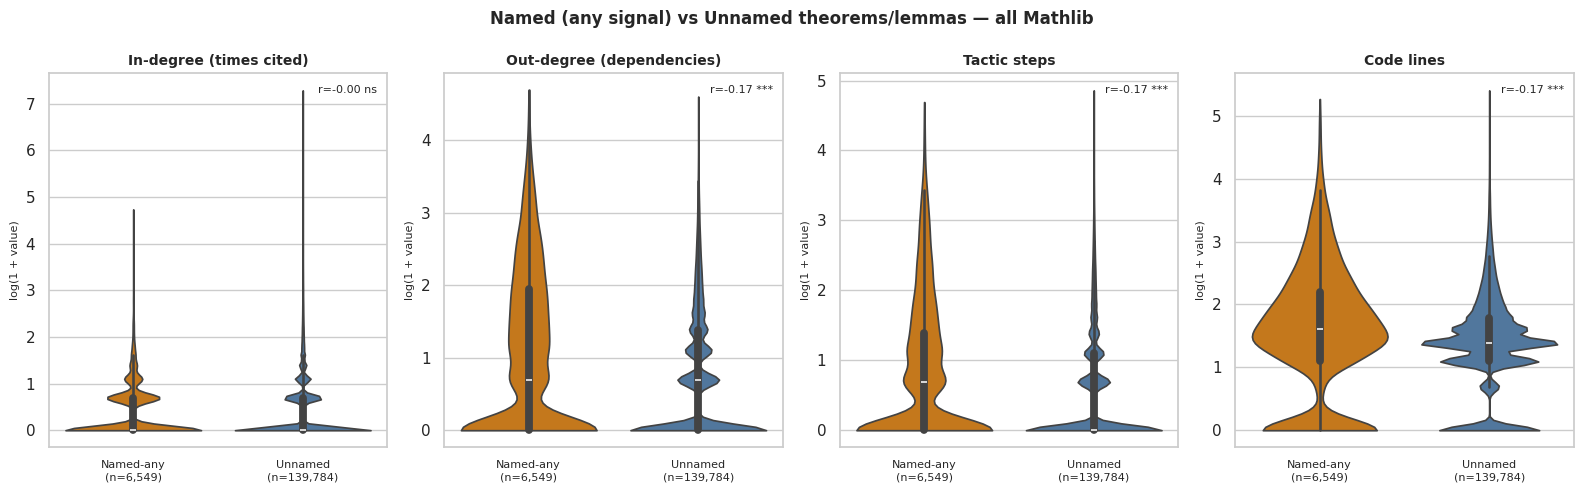

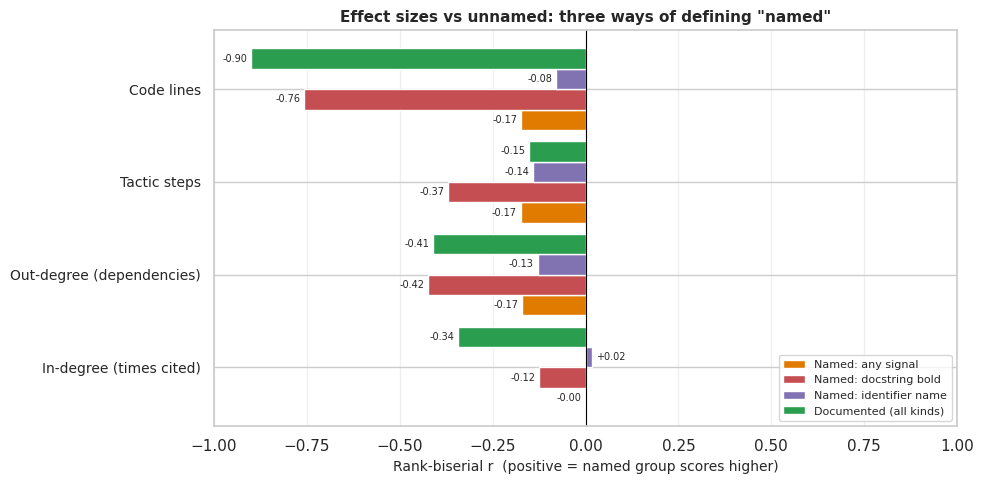

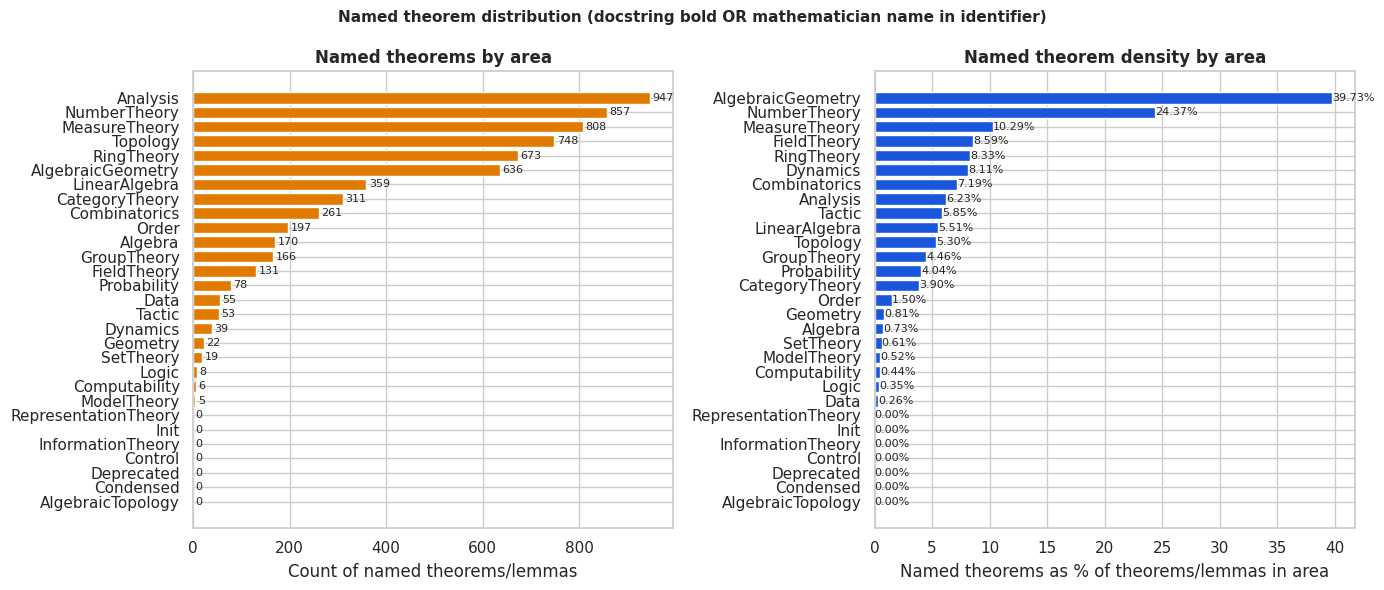

Name,Signal,Area,In-degree,Out-degree,Tactic steps,Code lines
not_and_or,doc,Logic,113,1,0,3
WeierstrassCurve.map_baseChange,id,AlgebraicGeometry,23,0,0,5
MeasureTheory.Measure.haveLebesgueDecomposition_add,id,MeasureTheory,19,0,0,3
tendsto_of_tendsto_of_tendsto_of_le_of_le,doc,Topology,18,0,0,7
Module.Baer,id,Algebra,17,0,0,4
LipschitzWith,doc id,Topology,16,0,0,4
MeasureTheory.lintegral_iSup,doc,MeasureTheory,16,51,51,63
add_pow,doc,Data,16,1,0,4
CauchySeq,id,Topology,16,0,0,5
WeierstrassCurve.Jacobian.smul_fin3_ext,id,AlgebraicGeometry,15,0,0,3


In [19]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as _stats

sns.set_theme(style='whitegrid', palette='muted')

# ── Load data ─────────────────────────────────────────────────────────────
feat = db.execute(r"""
    SELECT
        d.name,
        d.kind,
        d.module_parts[2]                                              AS area,
        COALESCE(ind.cnt, 0)                                           AS in_degree,
        COALESCE(outd.cnt, 0)                                          AS out_degree,
        (ds.docstring IS NOT NULL)                                     AS has_doc,
        regexp_matches(COALESCE(ds.docstring,''), '\*\*[^*]+\*\*')    AS is_named_doc,
        COALESCE(tc.n_steps, 0)                                        AS tactic_steps,
        COALESCE(ls.end_line - ls.start_line + 1, 0)                  AS code_lines
    FROM declarations d
    LEFT JOIN (SELECT dst, COUNT(*) AS cnt FROM dependencies GROUP BY dst) ind
           ON ind.dst = d.name
    LEFT JOIN (SELECT src, COUNT(*) AS cnt FROM dependencies GROUP BY src) outd
           ON outd.src = d.name
    LEFT JOIN docstrings ds ON ds.name = d.name
    LEFT JOIN (SELECT theorem_name, COUNT(*) AS n_steps FROM tactics GROUP BY 1) tc
           ON tc.theorem_name = d.name
    LEFT JOIN lean_source ls ON ls.name = d.name
    WHERE d.module_parts[1] = 'Mathlib'
""").df()

# Add identifier-based named flag (computed in previous cell)
feat['is_named_id']  = feat['name'].isin(named_by_id)
feat['is_named_any'] = feat['is_named_doc'] | feat['is_named_id']

# ── Group definitions ─────────────────────────────────────────────────────
thm = feat[feat['kind'].isin(['theorem', 'lemma'])].copy()

named_doc  = thm[ thm['is_named_doc'] & ~thm['is_named_id']]   # docstring only
named_id   = thm[~thm['is_named_doc'] &  thm['is_named_id']]   # identifier only
named_both = thm[ thm['is_named_doc'] &  thm['is_named_id']]   # both
named_any  = thm[ thm['is_named_any']]                          # union
unnamed    = thm[~thm['is_named_any']]

doc   = feat[feat['has_doc']]
nodoc = feat[~feat['has_doc']]

print(f"{'Named (docstring bold only)':35s}: {len(named_doc):,}")
print(f"{'Named (identifier name only)':35s}: {len(named_id):,}")
print(f"{'Named (both signals)':35s}: {len(named_both):,}")
print(f"{'Named (any signal — union)':35s}: {len(named_any):,}")
print(f"{'Unnamed theorems/lemmas':35s}: {len(unnamed):,}")

# ── Statistical tests ─────────────────────────────────────────────────────
METRICS = [
    ('in_degree',    'In-degree\n(times cited)'),
    ('out_degree',   'Out-degree\n(dependencies)'),
    ('tactic_steps', 'Tactic steps'),
    ('code_lines',   'Code lines'),
]

def mwu(a, b, label):
    a, b = a.dropna().values, b.dropna().values
    u, p = _stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - 2*u / (len(a) * len(b))
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return dict(metric=label, med_A=np.median(a), med_B=np.median(b),
                r=round(r, 3), p=round(p, 5), sig=sig)

named_any_results = [mwu(named_any[c], unnamed[c], l) for c, l in METRICS]
named_doc_results = [mwu(named_doc[c], unnamed[c], l) for c, l in METRICS]
named_id_results  = [mwu(named_id[c],  unnamed[c], l) for c, l in METRICS]
doc_results       = [mwu(doc[c],       nodoc[c],   l) for c, l in METRICS]

# ── Figure 1: Distributions — named (any) vs unnamed ─────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for col_i, (col, short_label) in enumerate(METRICS):
    ax = axes[col_i]
    lbl_a = f'Named-any\n(n={len(named_any):,})'
    lbl_b = f'Unnamed\n(n={len(unnamed):,})'
    plot_df = pd.concat([named_any[[col]].assign(group=lbl_a),
                         unnamed[[col]].assign(group=lbl_b)])
    plot_df[col] = np.log1p(plot_df[col])
    sns.violinplot(data=plot_df, x='group', y=col, ax=ax,
                   palette={lbl_a: '#e07b00', lbl_b: '#4477aa'},
                   inner='box', cut=0, density_norm='width')
    ax.set_title(short_label.replace('\n', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('log(1 + value)', fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    r_val = named_any_results[col_i]['r']
    ax.text(0.97, 0.97, f"r={r_val:+.2f} {named_any_results[col_i]['sig']}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8)
plt.suptitle('Named (any signal) vs Unnamed theorems/lemmas — all Mathlib',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'named_vs_unnamed.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Effect sizes across all three named definitions ─────────────
metric_labels = [l.replace('\n', ' ') for _, l in METRICS]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(METRICS)); w = 0.22
groups = [
    ('Named: any signal',      named_any_results, '#e07b00'),
    ('Named: docstring bold',  named_doc_results, '#c44e52'),
    ('Named: identifier name', named_id_results,  '#8172b2'),
    ('Documented (all kinds)', doc_results,        '#2a9d4e'),
]
for (label, results, color), offset in zip(groups, [-1.5*w, -0.5*w, 0.5*w, 1.5*w]):
    rs = [res['r'] for res in results]
    ax.barh(x + offset, rs, w, color=color, label=label)
    for i, rv in enumerate(rs):
        ax.text(rv + (0.01 if rv >= 0 else -0.01), x[i] + offset,
                f'{rv:+.2f}', va='center',
                ha='left' if rv >= 0 else 'right', fontsize=7)
ax.set_yticks(x); ax.set_yticklabels(metric_labels, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Rank-biserial r  (positive = named group scores higher)', fontsize=10)
ax.set_title('Effect sizes vs unnamed: three ways of defining "named"',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(-1, 1); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'named_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Area distribution (any signal) ─────────────────────────────
area_df = (thm.groupby('area')
              .agg(total=('name','count'), named=('is_named_any','sum'))
              .reset_index()
              .assign(density=lambda d: 100 * d['named'] / d['total'])
              .query('total >= 50')
              .sort_values('density', ascending=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
area_df_c = area_df.sort_values('named', ascending=True)
ax1.barh(area_df_c['area'], area_df_c['named'], color='#e07b00')
ax1.set_xlabel('Count of named theorems/lemmas'); ax1.set_title('Named theorems by area', fontweight='bold')
for i, (_, row) in enumerate(area_df_c.iterrows()):
    ax1.text(row['named'] + 5, i, str(int(row['named'])), va='center', fontsize=8)

ax2.barh(area_df['area'], area_df['density'], color='#1a56db')
ax2.set_xlabel('Named theorems as % of theorems/lemmas in area')
ax2.set_title('Named theorem density by area', fontweight='bold')
for i, (_, row) in enumerate(area_df.iterrows()):
    ax2.text(row['density'] + 0.02, i, f"{row['density']:.2f}%", va='center', fontsize=8)

plt.suptitle('Named theorem distribution (docstring bold OR mathematician name in identifier)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'named_by_area.png', dpi=150, bbox_inches='tight')
plt.show()

# ── HTML summary ──────────────────────────────────────────────────────────
def result_rows(results):
    html = ''
    for res in results:
        direction = ('↑ higher' if res['r'] > 0.05 else
                     '↓ lower'  if res['r'] < -0.05 else '≈ similar')
        col = '#0d6832' if res['r'] > 0.05 else ('#c5221f' if res['r'] < -0.05 else '#555')
        html += (f'<tr style="border-top:1px solid #eee">'
                 f'<td style="padding:4px 8px">{res["metric"].replace(chr(10)," ")}</td>'
                 f'<td style="padding:4px 8px;text-align:right">{res["med_A"]:.3g}</td>'
                 f'<td style="padding:4px 8px;text-align:right">{res["med_B"]:.3g}</td>'
                 f'<td style="padding:4px 8px;text-align:right;font-weight:bold">{res["r"]:+.3f}</td>'
                 f'<td style="padding:4px 8px;text-align:right">{res["p"]:.4f} {res["sig"]}</td>'
                 f'<td style="padding:4px 8px;color:{col}">{direction}</td>'
                 f'</tr>')
    return html

hdr = ('<tr style="background:#f6f8fa;border-bottom:2px solid #ddd">'
       '<th style="padding:4px 8px;text-align:left">Metric</th>'
       '<th style="padding:4px 8px;text-align:right">Med named</th>'
       '<th style="padding:4px 8px;text-align:right">Med unnamed</th>'
       '<th style="padding:4px 8px;text-align:right">Effect r</th>'
       '<th style="padding:4px 8px;text-align:right">p-value</th>'
       '<th style="padding:4px 8px;text-align:left">Direction</th>'
       '</tr>')

signal_chip = lambda color, text: (f'<span style="background:{color};color:#fff;padding:1px 5px;'
                                   f'border-radius:9px;font-size:0.78em">{text}</span>')

display(HTML(f'''
<div style="font-family:monospace;font-size:0.88em">

<div style="font-weight:bold;font-size:1.05em;margin:8px 0 6px 0">Signal breakdown (theorems/lemmas only)</div>
<table style="border-collapse:collapse;font-size:0.9em">
  <tr><td style="padding:2px 12px">{signal_chip("#c44e52","doc")} Docstring bold only</td>
      <td style="padding:2px 12px;font-weight:bold">{len(named_doc):,}</td></tr>
  <tr><td style="padding:2px 12px">{signal_chip("#8172b2","id")}  Identifier name only</td>
      <td style="padding:2px 12px;font-weight:bold">{len(named_id):,}</td></tr>
  <tr><td style="padding:2px 12px">{signal_chip("#c44e52","doc")} + {signal_chip("#8172b2","id")} Both signals</td>
      <td style="padding:2px 12px;font-weight:bold">{len(named_both):,}</td></tr>
  <tr style="border-top:2px solid #ddd">
      <td style="padding:2px 12px"><b>{signal_chip("#e07b00","any")} Union (named_any)</b></td>
      <td style="padding:2px 12px;font-weight:bold">{len(named_any):,}</td></tr>
  <tr><td style="padding:2px 12px">Unnamed</td>
      <td style="padding:2px 12px;font-weight:bold">{len(unnamed):,}</td></tr>
</table>

<div style="font-weight:bold;margin:14px 0 4px 0">Named (any, n={len(named_any):,}) vs Unnamed (n={len(unnamed):,})</div>
<table style="border-collapse:collapse;width:100%"><thead>{hdr}</thead>
<tbody>{result_rows(named_any_results)}</tbody></table>

<div style="font-weight:bold;margin:14px 0 4px 0">Named (docstring bold, n={len(named_doc)+len(named_both):,}) vs Unnamed</div>
<table style="border-collapse:collapse;width:100%"><thead>{hdr}</thead>
<tbody>{result_rows(named_doc_results)}</tbody></table>

<div style="font-weight:bold;margin:14px 0 4px 0">Named (identifier name, n={len(named_id)+len(named_both):,}) vs Unnamed</div>
<table style="border-collapse:collapse;width:100%"><thead>{hdr}</thead>
<tbody>{result_rows(named_id_results)}</tbody></table>

<div style="font-weight:bold;margin:14px 0 4px 0">Documented (n={len(doc):,}) vs Undocumented (n={len(nodoc):,})</div>
<table style="border-collapse:collapse;width:100%"><thead>{hdr}</thead>
<tbody>{result_rows(doc_results)}</tbody></table>
</div>
'''))

# ── Top named theorems by in-degree ──────────────────────────────────────
top_named = named_any.nlargest(20, 'in_degree')[
    ['name','area','in_degree','out_degree','tactic_steps','code_lines',
     'is_named_doc','is_named_id']
]
def sig_badges(doc, iid):
    return (('<span style="background:#c44e52;color:#fff;padding:1px 4px;border-radius:8px;font-size:0.75em">doc</span> ' if doc else '') +
            ('<span style="background:#8172b2;color:#fff;padding:1px 4px;border-radius:8px;font-size:0.75em">id</span>'   if iid else ''))

rows_html = ''.join(
    f'<tr style="border-top:1px solid #eee">'
    f'<td style="padding:3px 8px;color:#0366d6;font-weight:bold;white-space:nowrap">{r["name"]}</td>'
    f'<td style="padding:3px 8px;white-space:nowrap">{sig_badges(r["is_named_doc"], r["is_named_id"])}</td>'
    f'<td style="padding:3px 8px;color:#888;white-space:nowrap">{r["area"]}</td>'
    f'<td style="padding:3px 8px;text-align:right">{int(r["in_degree"]):,}</td>'
    f'<td style="padding:3px 8px;text-align:right">{int(r["out_degree"])}</td>'
    f'<td style="padding:3px 8px;text-align:right">{int(r["tactic_steps"])}</td>'
    f'<td style="padding:3px 8px;text-align:right">{int(r["code_lines"])}</td>'
    f'</tr>'
    for _, r in top_named.iterrows()
)
display(HTML(f'''
<div style="font-family:monospace;font-size:0.88em;margin-top:16px">
<div style="font-weight:bold;font-size:1.05em;margin-bottom:6px">Top 20 named theorems by in-degree</div>
<div style="overflow-x:auto">
<table style="border-collapse:collapse;min-width:max-content">
  <thead><tr style="background:#f6f8fa;border-bottom:2px solid #ddd">
    <th style="padding:4px 8px;text-align:left">Name</th>
    <th style="padding:4px 8px">Signal</th>
    <th style="padding:4px 8px;text-align:left">Area</th>
    <th style="padding:4px 8px;text-align:right">In-degree</th>
    <th style="padding:4px 8px;text-align:right">Out-degree</th>
    <th style="padding:4px 8px;text-align:right">Tactic steps</th>
    <th style="padding:4px 8px;text-align:right">Code lines</th>
  </tr></thead>
  <tbody>{rows_html}</tbody>
</table>
</div>
</div>
'''))